In [59]:
# Titanic Analysis with Perceptron

In [60]:
# Perceptron model

import numpy as np
import seaborn as sns

def unit_step_func(x):
  return np.where(x > 0, 1, 0)

class Perceptron:

  def __init__(self, learning_rate=0.01, n_iters=1000):
    self.lr = learning_rate
    self.n_iters = n_iters
    self.activation_func = unit_step_func
    self.weights = None
    self.bias = None

  def fit(self, x, y):
    n_samples, n_features = x.shape

    #init paramaters
    self.weights = np.random.randn(n_features) * 0.01
    self.bias = np.random.randn() * 0.01

    y_ = y

    # Learn weights
    for _ in range(self.n_iters):
      for idx, x_i in enumerate(x):
        linear_output = np.dot(x_i, self.weights) + self.bias
        y_predicted = self.activation_func(linear_output)

        # Perceptron update rule
        update = self.lr * (y_[idx] - y_predicted)
        self.weights += update * x_i
        self.bias += update



  def predict(self, x):
    linear_output = np.dot(x, self.weights) + self.bias
    y_predicted = self.activation_func(linear_output)
    return y_predicted

In [61]:
# Load the Titanic dataset
titanic = sns.load_dataset("titanic")
print(titanic.head(4))

# Keep only the columns we need
data = titanic[
    ["survived", "sex", "pclass", "age", "alone"]
].copy()

# Convert sex into numbers
data["sex"] = data["sex"].map({
    "male": 0,
    "female": 1
})

# Convert alone into numbers
data["alone"] = data["alone"].map({
    False: 0,
    True: 1
})

# Remove passengers whose age is missing
data = data.dropna()

# Create input data and correct answers
x = data[
    ["sex", "pclass", "age", "alone"]
].to_numpy()

y = data["survived"].to_numpy()

# Empty list to store every accuracy score
accuracies = []

# Test 10 different shuffled splits
for seed in range(10):
    np.random.seed(seed)

    # Create and shuffle passenger row numbers
    indices = np.arange(len(x))
    np.random.shuffle(indices)

    # Split 80% training and 20% testing
    split_index = int(len(x) * 0.8)

    train_indices = indices[:split_index]
    test_indices = indices[split_index:]

    x_train = x[train_indices]
    x_test = x[test_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]

    # Train a new perceptron for this split
    model = Perceptron(learning_rate=0.01,n_iters=1000)

    model.fit(x_train, y_train)

    # Make predictions
    predictions = model.predict(x_test)

    # Calculate and save accuracy
    accuracy = np.mean(predictions == y_test)
    accuracies.append(accuracy)

    print("Seed:",seed,"Accuracy:",accuracy * 100,"%")

# Average of all 10 accuracy scores
average_accuracy = np.mean(accuracies)

print("Average accuracy:",average_accuracy * 100,"%")


   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
Seed: 0 Accuracy: 81.11888111888112 %
Seed: 1 Accuracy: 63.63636363636363 %
Seed: 2 Accuracy: 70.62937062937063 %
Seed: 3 Accuracy: 79.02097902097903 %
Seed: 4 Accuracy: 60.13986013986013 %
Seed: 5 Accuracy: 79.72027972027972 %
Seed: 6 Accuracy: 68.53146853146853 %
Seed: 7 Accuracy: 83.91608391608392 %
Seed: 8 Accuracy: 63.63636363636363 %
Seed: 9

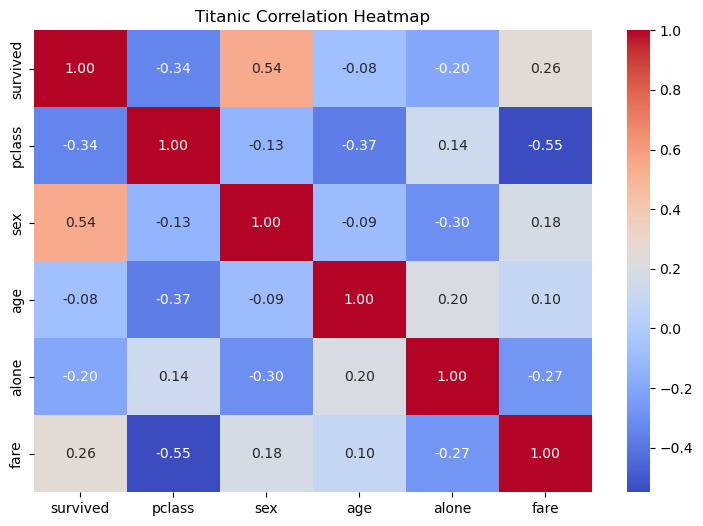

In [62]:
# Titanic Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
titanic = sns.load_dataset("titanic")

# Make a copy so the original dataset is not changed
data = titanic.copy()

# Convert sex from words into numbers
data["sex"] = data["sex"].map({
    "male": 0,
    "female": 1
})

# Convert alone from True/False into 1/0
data["alone"] = data["alone"].astype(int)

# Choose the columns for the heatmap
heatmap_data = data[
    [
        "survived",
        "pclass",
        "sex",
        "age",
        "alone",
        "fare"
    ]
]

# Create the correlation heatmap
plt.figure(figsize=(9, 6))

sns.heatmap(heatmap_data.corr(),annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Titanic Correlation Heatmap")
plt.show()